# SAIL quick start

A self-contained walk-through on synthetic data (no downloads, runs on CPU in about a minute):

1. build a spatial graph;
2. check that SAIL with fixed components reproduces the classical global Moran's I;
3. learn *SAIL Modes*, i.e. feature combinations that are maximally spatially coherent;
4. map where each mode is coherent with a permutation-tested LISA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sail
from sail.viz import overlay

sail.set_seed(0)

## 1. Data and graph

2,000 cells in the unit square with 10 features. Features 0 and 1 are dominated by the same
non-spatial noise, but their **difference** is a smooth spatial field. Each feature on its own looks
nearly random; only the combination is spatially coherent. The other 8 features are pure noise.

In [2]:
n, d = 2000, 10
rng = np.random.default_rng(0)
coords = rng.uniform(size=(n, 2))
field = np.sin(3 * np.pi * coords[:, 0]) * np.cos(2 * np.pi * coords[:, 1])
shared = 3 * rng.normal(size=n)
X = rng.normal(size=(n, d))
X[:, 0] = shared + field
X[:, 1] = shared
X = (X - X.mean(0)) / X.std(0)

g = sail.build_graph(coords, X, method="knn", k=16)
print(g.num_nodes, "nodes,", g.neighbors.shape[1], "neighbours each,", g.x.shape[1], "features")

2000 nodes, 16 neighbours each, 10 features


## 2. Classical statistics as a special case

With an identity feature map and a temperature that makes the kNN affinities uniform, the global
SAIL score is exactly the classical global Moran's I of each feature (row-standardised kNN weights).

In [3]:
classical = sail.SAIL(local_index="moran", learnable_temperature=False, init_temp=-1e4)
with torch.no_grad():
    I_sail = classical(g).global_scores[0].numpy()

# reference: Moran's I with a dense row-standardised kNN weight matrix
W = np.zeros((n, n))
W[np.repeat(np.arange(n), g.neighbors.shape[1]), g.neighbors.numpy().ravel()] = 1 / g.neighbors.shape[1]
I_ref = np.array([n / W.sum() * (x @ W @ x) / (x @ x) for x in (X - X.mean(0)).T])

print("Moran's I per feature:", np.round(I_sail, 3))
print("max |SAIL - classical| =", np.abs(I_sail - I_ref).max())

Moran's I per feature: [ 0.014 -0.004  0.005  0.001 -0.001  0.007  0.002  0.006 -0.004  0.014]
max |SAIL - classical| = 1.6375564706322399e-09


Every single feature has Moran's I close to zero, so a per-feature analysis would miss the
hidden pattern.

## 3. Learn SAIL Modes

`SAILModes` learns an orthonormal projection `W` (d x h) whose columns minimise Geary's C
(maximise spatial coherence), with decorrelation and sparsity regularisers.

Geary's C per mode (lower = more coherent): [0.007 0.908 0.921]


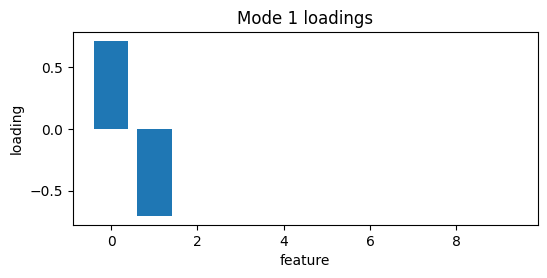

In [4]:
# a small toy problem: constant learning rate and a light sparsity penalty
modes = sail.SAILModes(input_dim=d, n_modes=3, local_index="geary", epochs=300,
                       lr=0.1, scheduler=None, lambda_sparse=0.1)
modes.fit([g], verbose=False)

print("Geary's C per mode (lower = more coherent):", np.round(modes.scores([g])[0], 3))
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.bar(range(d), modes.W[:, 0].cpu().numpy())
ax.set(xlabel="feature", ylabel="loading", title="Mode 1 loadings")
plt.show()

Mode 1 loads on features 0 and 1 with opposite signs: it recovers the hidden field
`X[:, 0] - X[:, 1]`.

## 4. Where is the mode coherent?

`sail.lisa` runs a conditional permutation test per node (BH-corrected) and returns
High-High / Low-Low / High-Low / Low-High / not-significant labels.

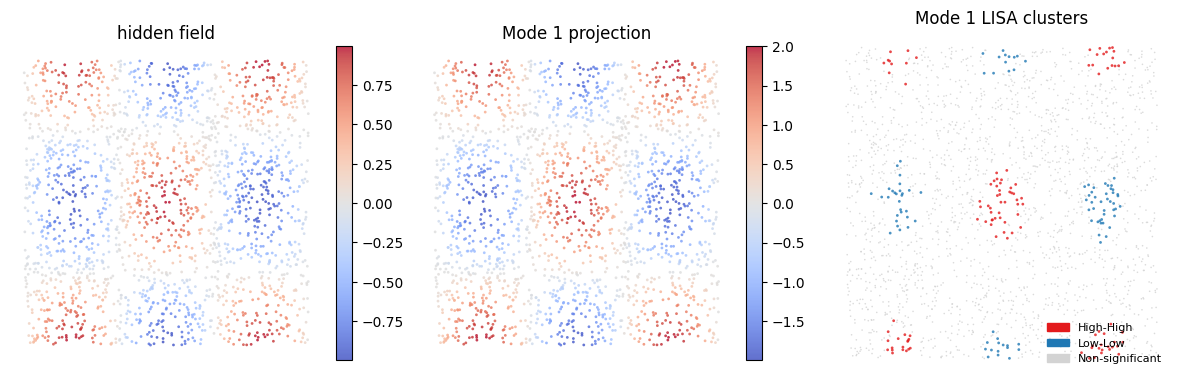

In [5]:
out = modes.transform(g)
labels = sail.lisa(g, modes.model, modes=0, permutations=499)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
overlay(coords, field, ax=axs[0], title="hidden field")
overlay(coords, out.z[0][:, 0].cpu().numpy(), ax=axs[1], title="Mode 1 projection")
overlay(coords, labels, kind="lisa", ax=axs[2], title="Mode 1 LISA clusters")
plt.show()

## Next steps

* Several graphs (e.g. one per patient) are passed as a list; the modes are shared and
  `modes.scores(graphs)` returns one row per graph, ready for association or survival analysis.
* `sail.supervised.SAILPredictor` uses SAIL as a backbone for graph-level prediction.
* The paper experiments are in `experiments/`; see the README.